# **Cleaning, analysis and visualisation of Netflix data base**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Reading data**

In [5]:
import kaggle
kaggle.api.authenticate()
kaggle.api.dataset_download_files('ariyoomotade/netflix-data-cleaning-analysis-and-visualization', path='.', unzip=True)
df = pd.read_csv('netflix1.csv')

Dataset URL: https://www.kaggle.com/datasets/ariyoomotade/netflix-data-cleaning-analysis-and-visualization


In [6]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [7]:
print(df.shape)
print(df.describe())
print(df.info())
print(df.duplicated().sum())
df

(8790, 10)
       release_year
count   8790.000000
mean    2014.183163
std        8.825466
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None
0


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


**Deleting duplicates**

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

**Sorting by show id**

In [9]:
df["id_num"]=df["show_id"].str[1:].astype(int)
df.sort_values("id_num",inplace=True)
df.reset_index(drop=True, inplace=True)
df.drop(columns=["id_num","show_id"],inplace=True)
df

,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Not Given,South Africa,9/24/2021,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Not Given,Pakistan,9/24/2021,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Not Given,India,9/24/2021,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...
8785,Movie,Zodiac,David Fincher,United States,11/20/2019,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8786,TV Show,Zombie Dumb,Not Given,Pakistan,7/1/2019,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8787,Movie,Zombieland,Ruben Fleischer,United States,11/1/2019,2009,R,88 min,"Comedies, Horror Movies"
8788,Movie,Zoom,Peter Hewitt,United States,1/11/2020,2006,PG,88 min,"Children & Family Movies, Comedies"


In [10]:
df.shape
print(df.sort_values("director").head())

       type       title         director country date_added  release_year  \
3537  Movie    Watchman      A. L. Vijay   India   9/4/2019          2019   
6073  Movie   Abhinetri      A. L. Vijay   India   5/1/2018          2016   
2389  Movie  Asura Guru     A. Raajdheep   India  6/13/2020          2020   
5548  Movie   Salaakhen        A. Salaam   India   4/1/2017          1975   
4681  Movie      Spyder  A.R. Murugadoss   India  8/28/2018          2017   

     rating duration                                          listed_in  
3537  TV-14   93 min             Comedies, Dramas, International Movies  
6073  TV-14  131 min   Comedies, International Movies, Sci-Fi & Fantasy  
2389  TV-14  117 min                       Dramas, International Movies  
5548  TV-14  134 min  Action & Adventure, International Movies, Musi...  
4681  TV-14  140 min           Action & Adventure, International Movies  


In [11]:
df["duration"]=df["duration"].str.replace(" Season","s").str.replace(" Seasons","s")
df.head()

,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Not Given,South Africa,9/24/2021,2021,TV-MA,2ss,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1s,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Not Given,Pakistan,9/24/2021,2021,TV-MA,1s,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Not Given,India,9/24/2021,2021,TV-MA,2ss,"International TV Shows, Romantic TV Shows, TV ..."


In [12]:
df["duration"]=df["duration"].str.replace("ss","s")
df.head()

,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Not Given,South Africa,9/24/2021,2021,TV-MA,2s,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1s,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Not Given,Pakistan,9/24/2021,2021,TV-MA,1s,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Not Given,India,9/24/2021,2021,TV-MA,2s,"International TV Shows, Romantic TV Shows, TV ..."


In [13]:
uni_dur=df[df["type"]=="TV Show"]
uni_dur["duration"].unique()

array(['2s', '1s', '9s', '4s', '5s', '3s', '6s', '7s', '10s', '8s', '17s',
       '13s', '15s', '12s', '11s'], dtype=object)

## **Visualization and analysis**

In [14]:
unique_types = df["type"].unique()
unique_types

array(['Movie', 'TV Show'], dtype=object)

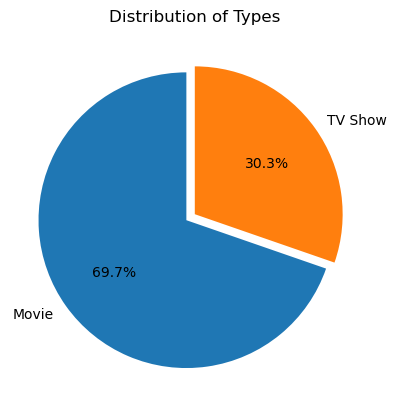

In [15]:
plt.pie(df["type"].value_counts(), labels=unique_types, autopct="%1.1f%%", startangle=90, explode=[0.07, 0])
plt.title("Distribution of Types")
plt.show()

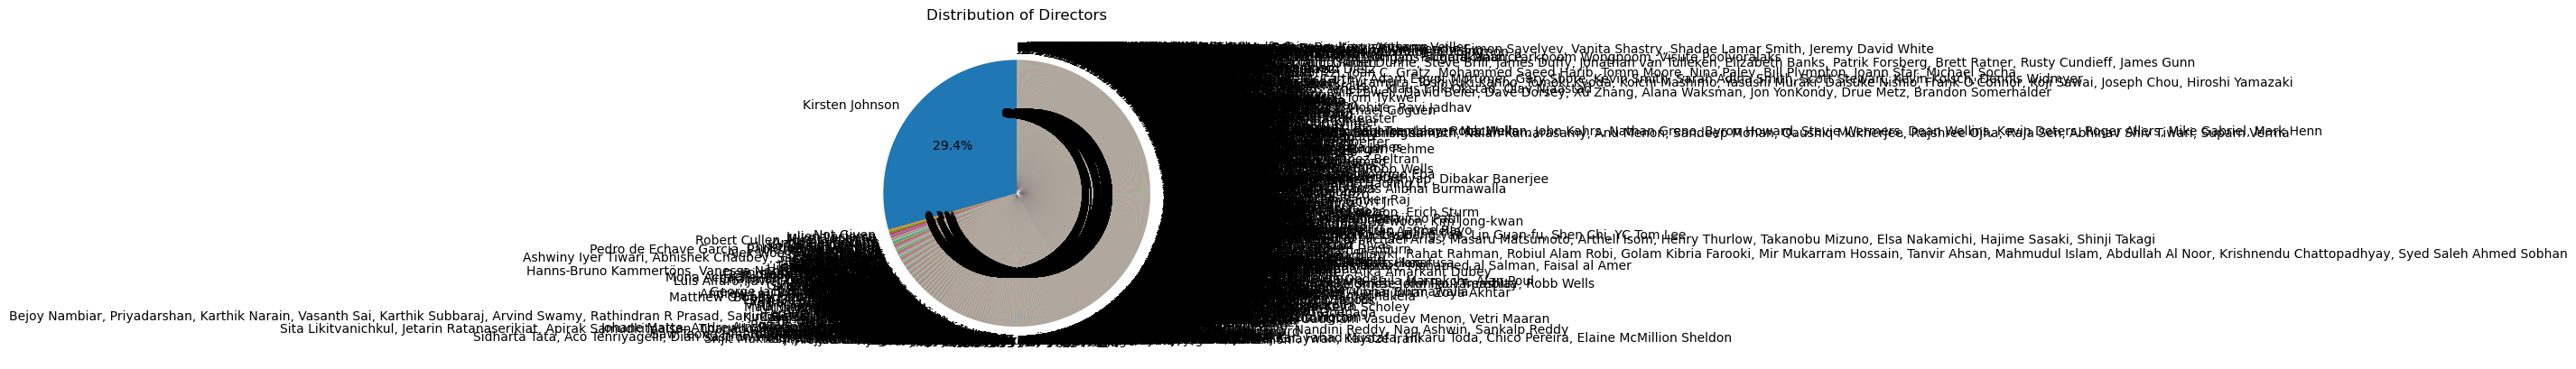

In [ ]:
plt.pie(df["director"].value_counts(), labels=df["director"].unique(), autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Directors")
plt.show()

As we could predict it doesn't work out very well, so we will take only 10 directors which have the most amount of movies/series.